**End-to-End Machine Learning Workflow with Classical Models working with tabular data**

**Portfolio goals:** clarity, reasoning, tradeoffs, and clean experimentation over squeezing out maximum accuracy.

## 1. Introduction & Problem Framing

In this notebook, we build and evaluate models that classify breast tumors as **benign** or **malignant** using the **Breast Cancer Wisconsin dataset**.


## Quick Facts
- **Dataset**: Breast Cancer Wisconsin (UCI)
- **Task**: Binary classification
- **Models**: Logistic Regression, MLP
- **Framework**: PyTorch
- **Evaluation**: Accuracy, F1, ROC-AUC
- **Focus**: Model comparison & feature scaling

**Why this dataset?**
- It's a classic, well-understood supervised learning problem
- It's **tabular** (unlike MNIST), so we can demonstrate tabular best practices: pipelines, leakage prevention, thresholding

**Workflow philosophy:**
- Start with simple baselines
- Use a consistent evaluation protocol
- Analyze mistakes and tradeoffs


## 2. Imports & Environment Setup

We'll import:
- Core numeric + plotting libraries
- scikit-learn modeling + evaluation utilities
- (Optional) PyTorch for a small MLP comparison

> Note: For small tabular datasets, GPU acceleration is usually not the bottleneck.


In [ ]:
import os
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
)

# Optional: PyTorch (only used in Section 14)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

def get_torch_device():
    """Return best available torch device (CUDA > MPS > CPU)."""
    if not TORCH_AVAILABLE:
        return None
    if torch.cuda.is_available():
        return torch.device("cuda")
    # Apple Silicon
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_torch_device()
print("Torch available:", TORCH_AVAILABLE)
print("Torch device:", device)


Torch available: True
Torch device: mps


## 3. Load & Inspect the Dataset

We will:
- Load the dataset
- Convert it into a pandas DataFrame
- Inspect shape, columns, and class balance

Key questions:
- Are there missing values?
- Are classes imbalanced?
- Do features look like they need scaling?


In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

target_names = list(data.target_names)  # usually ['malignant', 'benign']
print("Target names:", target_names)
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(), "\n")

display(X.head())
display(X.describe().T.head(10))

print("Missing values (total):", int(X.isna().sum().sum()))


Target names: ['malignant', 'benign']
X shape: (569, 30)
y distribution:
 target
1    357
0    212
Name: count, dtype: int64 



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


Missing values (total): 0


## 4. Data Preparation & Train/Test Splits

Important tabular best practice:
- Use **stratified splits** (preserve class ratio)
- Use **pipelines** so scaling is fit only on the training data

We'll create:
- Train set
- Validation set
- Test set (held out until the end)


In [ ]:
# Split into train+temp and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Split train+temp into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Val class balance:\n", y_val.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


Train: (341, 30)  Val: (114, 30)  Test: (114, 30)
Train class balance:
 target
1    0.627566
0    0.372434
Name: proportion, dtype: float64
Val class balance:
 target
1    0.622807
0    0.377193
Name: proportion, dtype: float64
Test class balance:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


All splits are stratified to preserve class balance and reduce evaluation variance, which is especially important for medical classification tasks.

## 5. Exploratory Data Analysis (EDA)

We'll do lightweight EDA to build intuition:
- Feature distributions
- Correlations
- A couple of class-conditional comparisons

> Goal: understand the data *just enough* to make model choices feel justified.


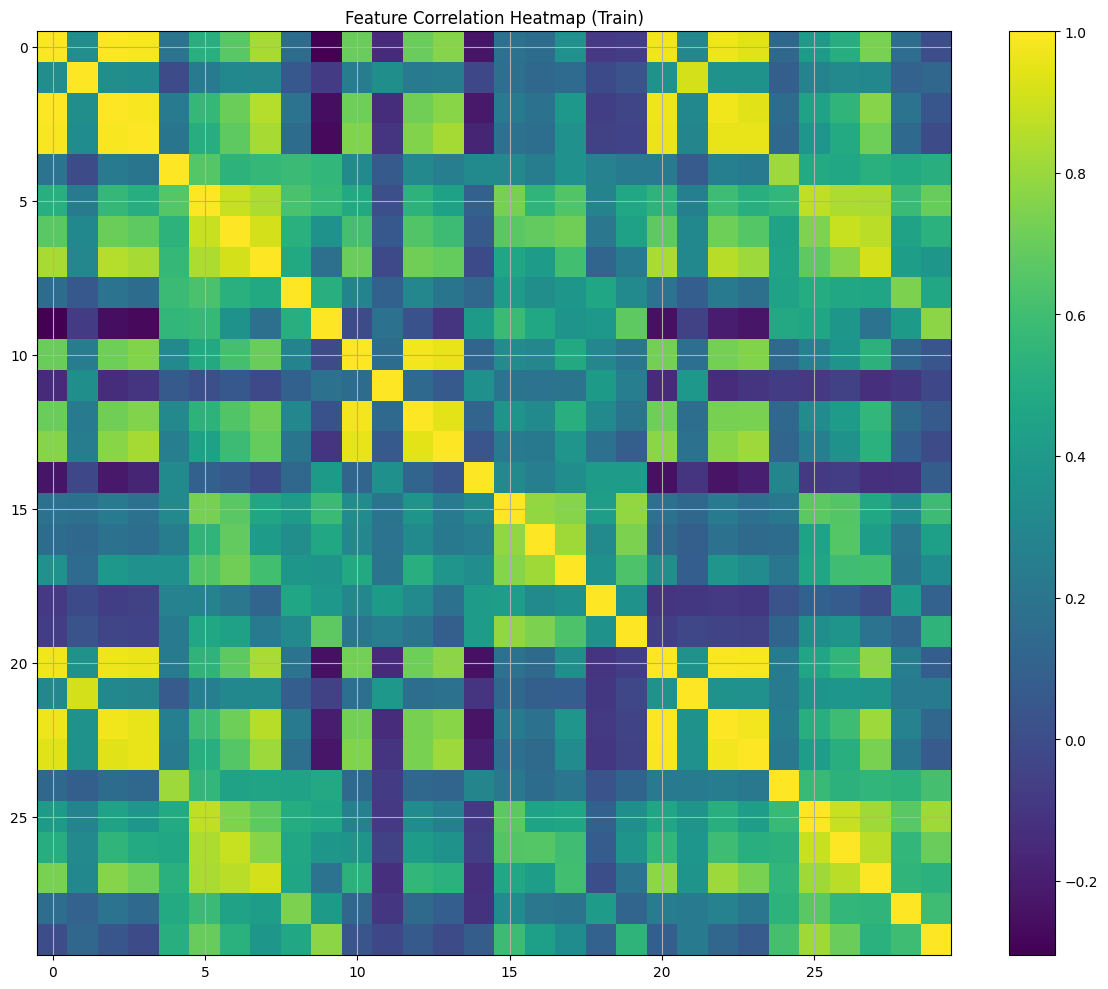

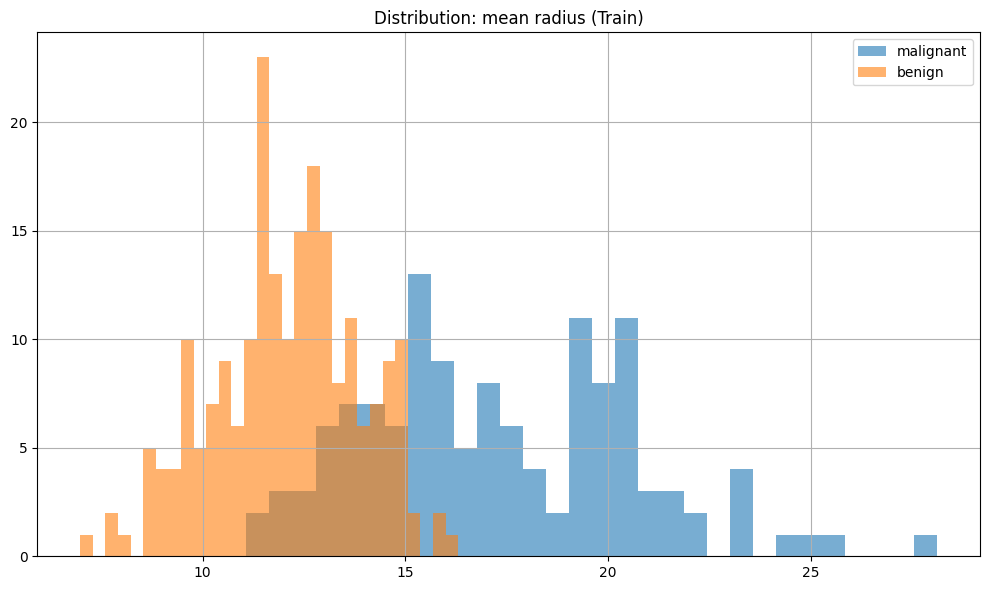

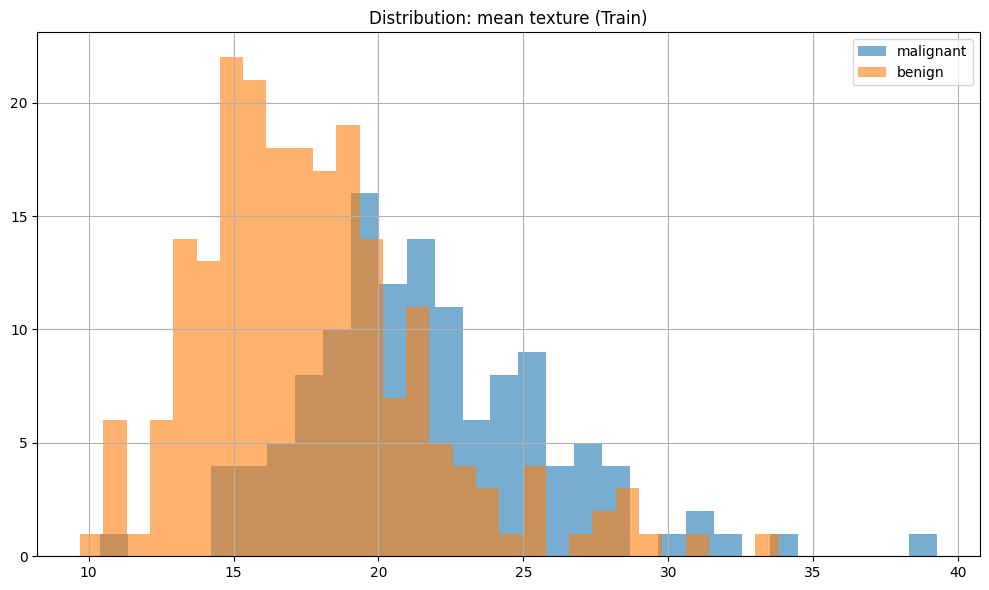

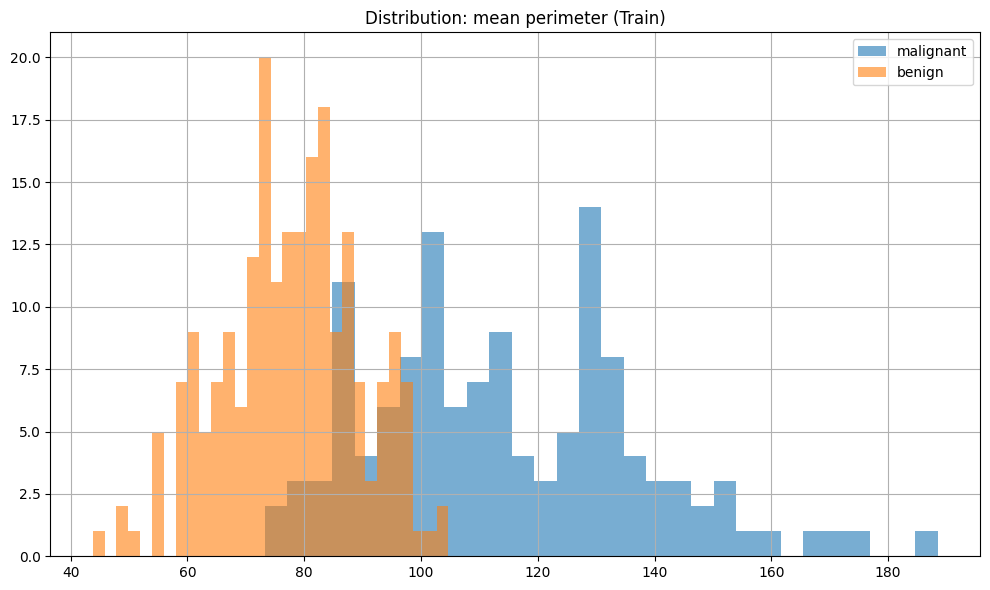

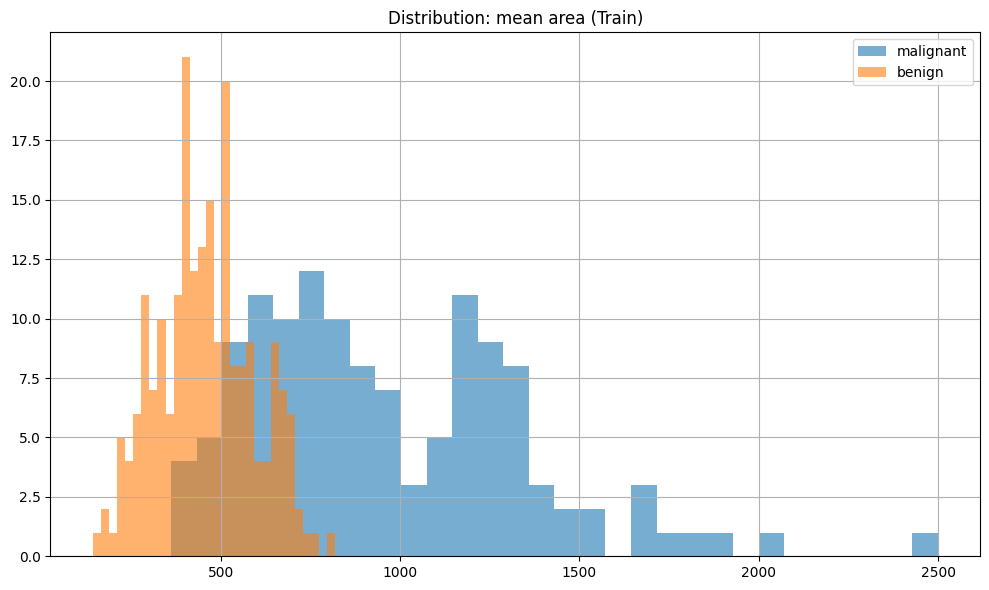

In [ ]:
# Correlation heatmap (matplotlib-only)
corr = X_train.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.title("Feature Correlation Heatmap (Train)")
plt.colorbar()
plt.tight_layout()
plt.show()

# Simple distribution plot for a few features
feature_subset = ["mean radius", "mean texture", "mean perimeter", "mean area"]
X_plot = X_train[feature_subset].copy()
X_plot["target"] = y_train.values

for feat in feature_subset:
    plt.figure()
    plt.hist(X_plot.loc[X_plot["target"] == 0, feat], bins=30, alpha=0.6, label=target_names[0])
    plt.hist(X_plot.loc[X_plot["target"] == 1, feat], bins=30, alpha=0.6, label=target_names[1])
    plt.title(f"Distribution: {feat} (Train)")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6. Evaluation Strategy & Metrics

We'll report multiple metrics because accuracy alone can hide failure modes.

**Metrics:**
- Accuracy (easy baseline)
- ROC-AUC (ranking quality across thresholds)
- Precision / Recall / F1 (threshold-dependent)
- Confusion matrix (interpretable error counts)

**Important context idea:**
- In many medical settings, false negatives can be more costly than false positives.
- We'll later discuss **threshold tuning** as a principled way to control that tradeoff.


In [ ]:
def plot_roc(y_true, y_proba, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_precision_recall(y_true, y_proba, title="Precision-Recall Curve"):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    plt.figure()
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def show_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 7. Baseline Model: Logistic Regression

We start with Logistic Regression because:
- It's a strong baseline for tabular data
- It's fast and stable
- It's relatively interpretable (coefficients)

We also put scaling into a Pipeline to prevent leakage.


In [ ]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        n_jobs=-1,
        random_state=SEED
    ))
])

logreg.fit(X_train, y_train)

val_proba = logreg.predict_proba(X_val)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

### Evaluation Metrics (Validation Set)

We evaluate models using multiple complementary metrics:

- **Accuracy** as a baseline sanity check
- **ROC-AUC** to measure ranking quality independent of threshold
- **Precision / Recall / F1** to understand class-specific tradeoffs
- **Confusion Matrix** to inspect concrete error counts

Unless otherwise stated, metrics in this section are computed on the **validation set**.


Validation accuracy: 0.9912280701754386
Validation ROC-AUC: 0.9980347199475925

Classification report (val):

              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        43
      benign       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



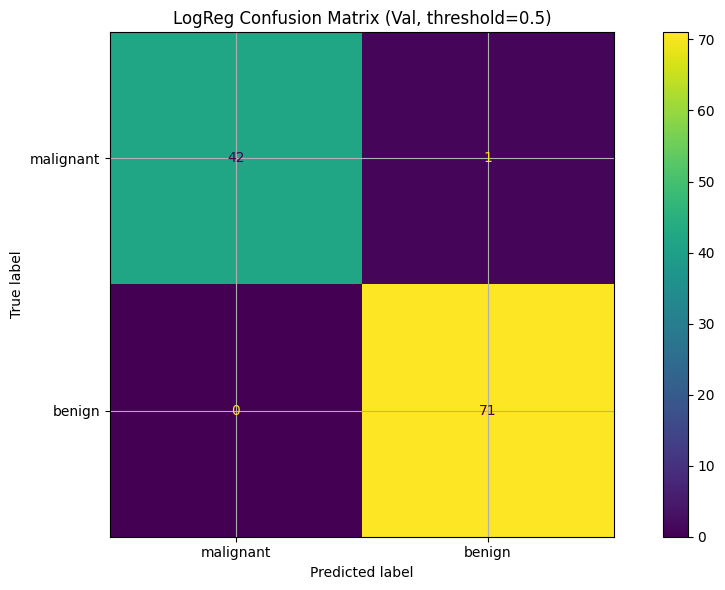

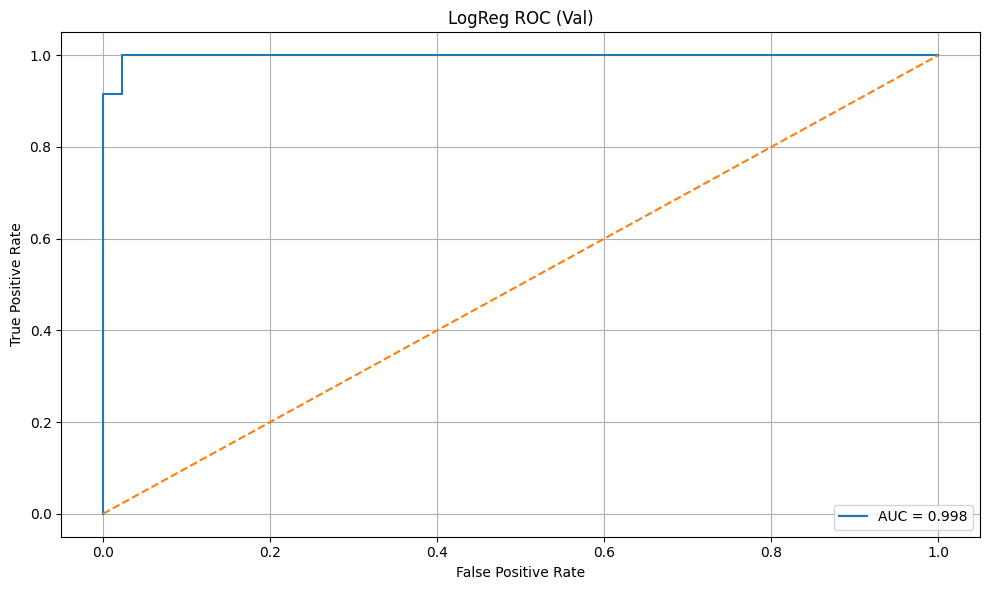

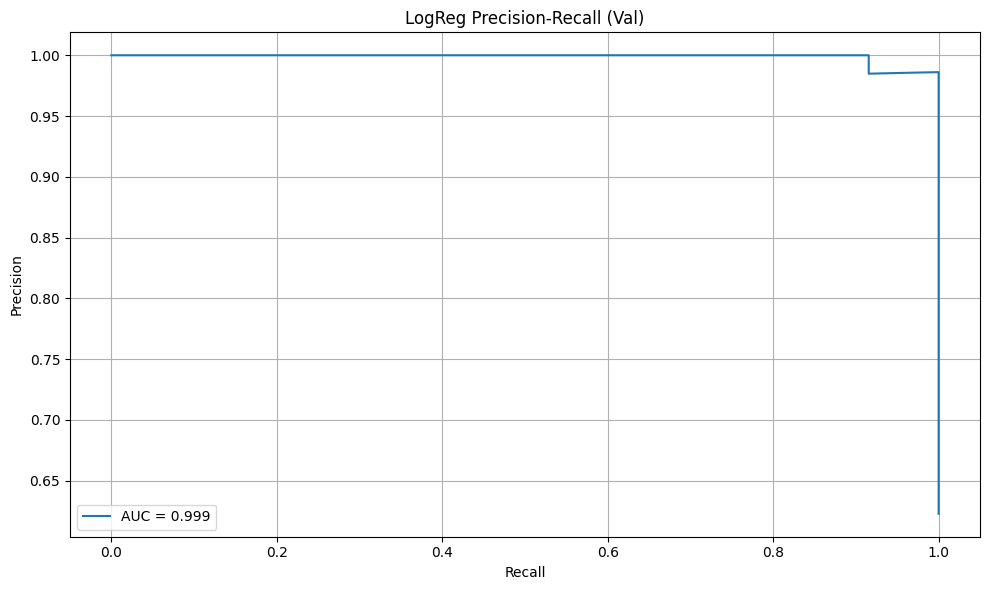

In [ ]:
print("Validation accuracy:", accuracy_score(y_val, val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_proba))
print("\nClassification report (val):\n")
print(classification_report(y_val, val_pred, target_names=target_names))

show_confusion_matrix(y_val, val_pred, title="LogReg Confusion Matrix (Val, threshold=0.5)")
plot_roc(y_val, val_proba, title="LogReg ROC (Val)")
plot_precision_recall(y_val, val_proba, title="LogReg Precision-Recall (Val)")


### Summary
At threshold=0.5, the baseline misses 1 malignant case on validation. In a medical screening context this error type is often more costly than a false positive, so later we’ll revisit threshold selection to trade precision for higher malignant recall.

## 8. Baseline Results & What They Suggest

The Logistic Regression baseline performs extremely well on the validation set, with ROC-AUC near 1.0. This suggests the model ranks malignant vs benign cases cleanly across thresholds (not just at a single decision cutoff).

### Confusion matrix (threshold = 0.5)

At the default threshold of 0.5, the model makes very few mistakes. The most important error type to inspect is a **false negative** (malignant predicted as benign). In many screening or diagnostic-support contexts, false negatives are more costly than false positives, so later we revisit threshold selection to trade precision for higher malignant recall.

### Why the baseline can be this strong on this dataset

The Breast Cancer Wisconsin dataset is known to be relatively “well-behaved”:
- Features are engineered summary statistics with strong signal.
- The dataset is small and clean with low missingness.
- Many features are highly predictive even for linear models.

This makes strong baseline performance plausible — but it also means improvements from more complex models may be incremental.

Despite strong aggregate performance, these metrics alone are insufficient for decision-making in a medical context. A small number of false negatives can be unacceptable, and high ROC-AUC does not guarantee an appropriate operating point.  

Therefore, in the following sections we:
1. Interpret which features drive predictions,
2. Examine misclassifications and borderline cases,
3. Explicitly tune the decision threshold to reflect domain priorities.


### Next steps

Even with excellent aggregate metrics, it’s still important to:
1. Interpret what the model learned (feature effects / importance).
2. Analyze mistakes and borderline cases.
3. Select an operating threshold aligned with the domain’s priorities (e.g., minimizing false negatives).

## 9. Interpreting the Baseline Model

We'll inspect the Logistic Regression coefficients.

Caveat:
- Coefficients are easiest to interpret when features are standardized.
- High correlation among features can make coefficients unstable.

Note: In this dataset, class `0` corresponds to malignant and class `1` to benign.  
Positive coefficients increase the log-odds of predicting benign, while negative coefficients push predictions toward malignant.

,feature,coef,abs_coef
21,worst texture,-1.133094,1.133094
10,radius error,-0.974058,0.974058
27,worst concave points,-0.956965,0.956965
20,worst radius,-0.932302,0.932302
23,worst area,-0.911293,0.911293
28,worst symmetry,-0.796446,0.796446
22,worst perimeter,-0.794682,0.794682
13,area error,-0.755694,0.755694
7,mean concave points,-0.661334,0.661334
26,worst concavity,-0.648697,0.648697


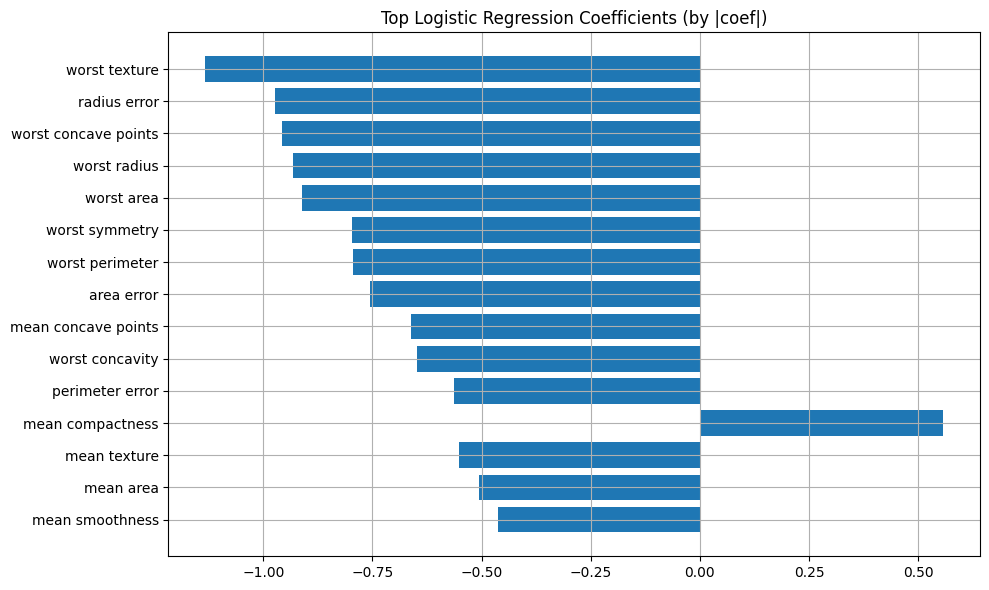

In [ ]:
# Extract coefficients from the pipeline
coef = logreg.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coef,
    "abs_coef": np.abs(coef),
}).sort_values("abs_coef", ascending=False)

display(coef_df.head(15))

plt.figure()
top = coef_df.head(15).iloc[::-1]
plt.barh(top["feature"], top["coef"])
plt.title("Top Logistic Regression Coefficients (by |coef|)")
plt.tight_layout()
plt.show()


### Summary

Because many features are correlated, coefficient signs/magnitudes should be interpreted as conditional effects (holding other standardized features constant), not as standalone importance.
**Note on coefficient direction:** in this dataset `0 = malignant` and `1 = benign`.  
For Logistic Regression, a **positive coefficient increases the log-odds of class 1 (benign)**, while a **negative coefficient pushes predictions toward malignant**.


## 10. Error Analysis
We'll look at:
- Most confident wrong predictions
- Borderline cases near the decision threshold

This helps answer:
- Are errors random noise or systematic?
- Is there a threshold that better matches our priorities?


In [ ]:
# Most confident wrong predictions on validation set
val_df = X_val.copy()
val_df["y_true"] = y_val.values
val_df["y_proba"] = val_proba
val_df["y_pred"] = val_pred
val_df["correct"] = (val_df["y_true"] == val_df["y_pred"]) 

wrong = val_df[val_df["correct"] == False].copy()
wrong["confidence"] = np.where(wrong["y_pred"] == 1, wrong["y_proba"], 1 - wrong["y_proba"])
wrong = wrong.sort_values("confidence", ascending=False)

display(wrong[["y_true", "y_pred", "y_proba", "confidence"]].head(10))

# Borderline cases near 0.5
border = val_df.copy()
border["dist_from_0.5"] = np.abs(border["y_proba"] - 0.5)
border = border.sort_values("dist_from_0.5", ascending=True)
display(border[["y_true", "y_pred", "y_proba", "dist_from_0.5"]].head(10))


,y_true,y_pred,y_proba,confidence
135,0,1,0.861839,0.861839


,y_true,y_pred,y_proba,dist_from_0.5
157,1,1,0.503234,0.003234
89,1,1,0.521396,0.021396
514,0,0,0.444452,0.055548
13,0,0,0.320153,0.179847
560,1,1,0.718715,0.218715
49,1,1,0.746541,0.246541
86,0,0,0.176852,0.323148
39,0,0,0.173243,0.326757
489,0,0,0.150031,0.349969
491,1,1,0.859024,0.359024


While the absolute number of errors is small, inspecting these cases helps validate that mistakes are not driven by obvious data issues or leakage.

## 11. Improved Model: Tree-Based Methods

Next we try a more expressive model that can capture nonlinearities and feature interactions.

Candidates:
- RandomForestClassifier
- GradientBoostingClassifier
- HistGradientBoostingClassifier (often strong, fast)

We'll keep tuning modest and focus on clean comparison.

We initially use a default decision threshold of `0.5`, and later revisit this choice during threshold optimization.

HGB Validation accuracy: 0.9473684210526315
HGB Validation ROC-AUC: 0.9895185063871602

Classification report (val):

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



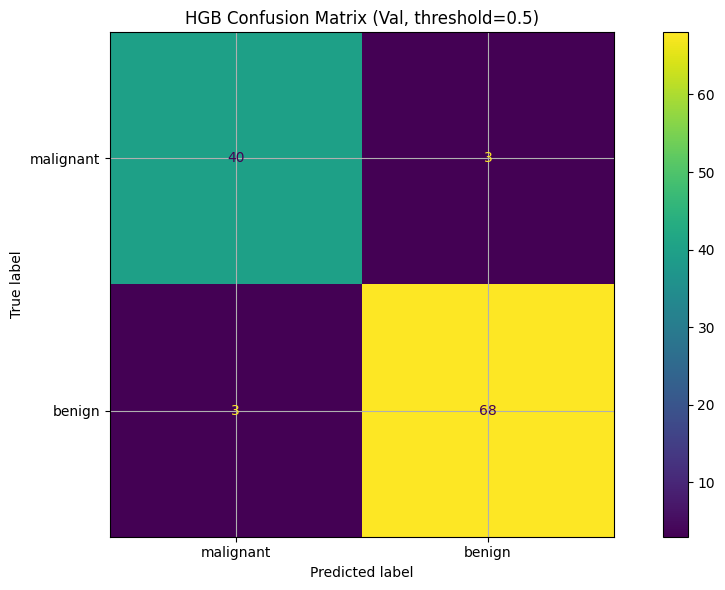

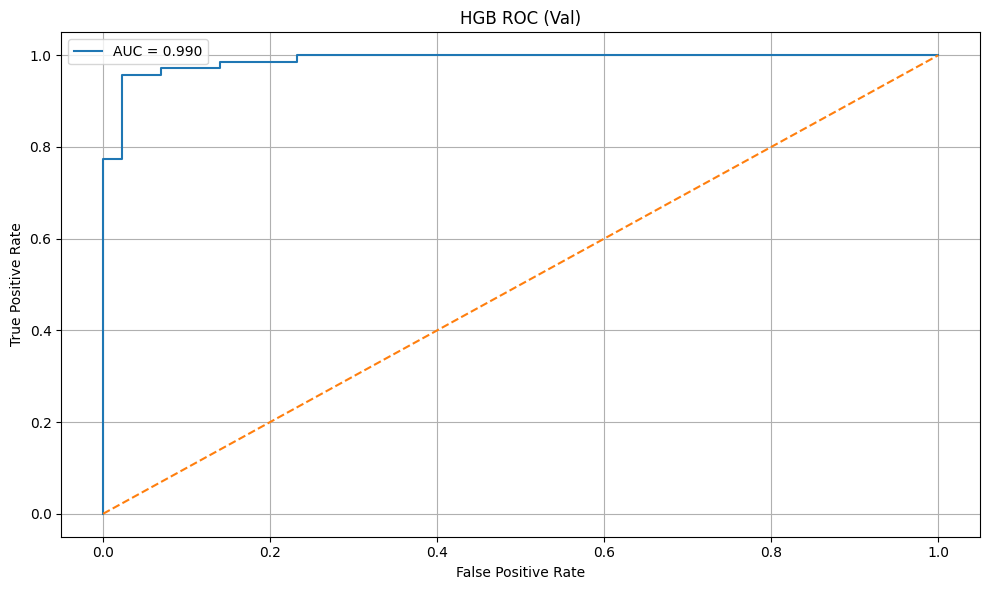

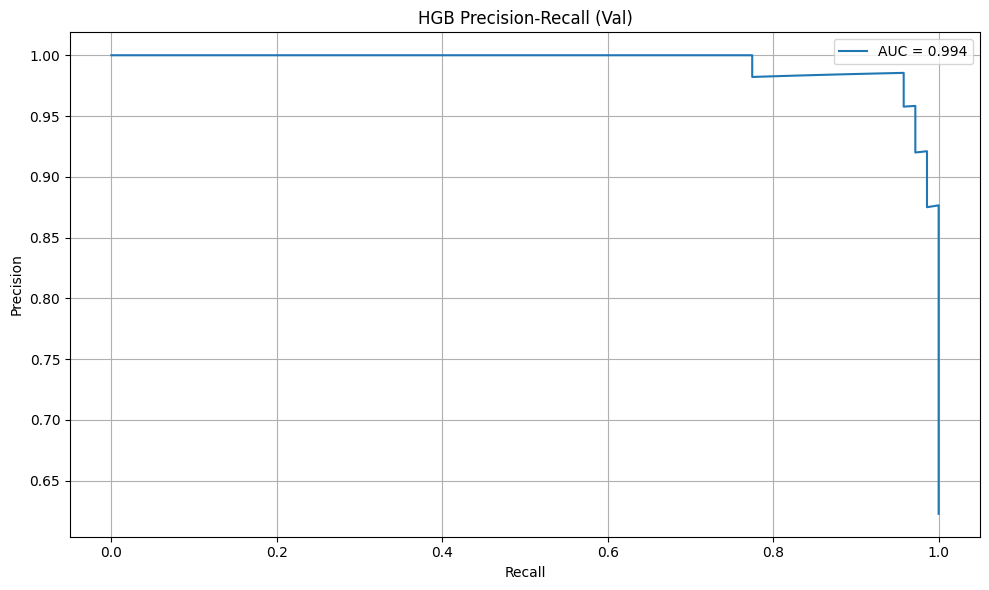

In [ ]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=SEED)
hgb.fit(X_train, y_train)

val_proba_hgb = hgb.predict_proba(X_val)[:, 1]
val_pred_hgb = (val_proba_hgb >= 0.5).astype(int)

print("HGB Validation accuracy:", accuracy_score(y_val, val_pred_hgb))
print("HGB Validation ROC-AUC:", roc_auc_score(y_val, val_proba_hgb))
print("\nClassification report (val):\n")
print(classification_report(y_val, val_pred_hgb, target_names=target_names))

show_confusion_matrix(y_val, val_pred_hgb, title="HGB Confusion Matrix (Val, threshold=0.5)")
plot_roc(y_val, val_proba_hgb, title="HGB ROC (Val)")
plot_precision_recall(y_val, val_proba_hgb, title="HGB Precision-Recall (Val)")


## 12. Model Comparison

Compare Logistic Regression vs Tree-based model:
- ROC-AUC, PR-AUC
- Confusion matrices
- Error analysis patterns

Discuss tradeoffs:
- Interpretability vs flexibility
- Stability / sensitivity to preprocessing


In [ ]:
comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_roc_auc": roc_auc_score(y_val, val_proba),
    },
    {
        "model": "HistGradientBoosting",
        "val_accuracy": accuracy_score(y_val, val_pred_hgb),
        "val_roc_auc": roc_auc_score(y_val, val_proba_hgb),
    },
]).sort_values("val_roc_auc", ascending=False)

display(comparison)


,model,val_accuracy,val_roc_auc
0,Logistic Regression,0.991228,0.998035
1,HistGradientBoosting,0.947368,0.989519


Based on validation performance and qualitative considerations, we select **Logistic Regression** as the final model for test evaluation.

While the tree-based model captures nonlinear interactions, it does not outperform the linear baseline on this dataset. Given the strong performance, interpretability, and stability of Logistic Regression, increased model complexity does not appear justified here.

We therefore proceed with the **tuned Logistic Regression pipeline** and a **validation-selected decision threshold** for final evaluation.


## 13. Optimization Experiments

We’ll do small, principled optimization experiments:
- Cross-validated hyperparameter search
- Decision-threshold tuning

Key idea:
> Optimization should be measured, justified, and repeatable.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Example: regularization sweep for Logistic Regression
param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0, 100.0]
}

logreg_grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=-1,
)

logreg_grid.fit(X_train, y_train)
print("Best params:", logreg_grid.best_params_)
print("Best CV ROC-AUC:", logreg_grid.best_score_)

best_logreg = logreg_grid.best_estimator_
val_proba_best = best_logreg.predict_proba(X_val)[:, 1]

# Threshold tuning example: choose threshold maximizing F1 on validation
# Tune threshold using P(malignant) directly (clearer for clinical framing)

# Identify index for malignant class in predict_proba columns
# In sklearn, classes_ is sorted: typically [0, 1] => [malignant, benign]
classes = best_logreg.named_steps["model"].classes_
idx_malignant = int(np.where(classes == 0)[0][0])  # class 0 = malignant

proba_malignant = best_logreg.predict_proba(X_val)[:, idx_malignant]

thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for thr in thresholds:
    # predict malignant if P(malignant) >= thr
    pred_malignant = (proba_malignant >= thr).astype(int)  # 1 means malignant (custom)
    y_true_malignant = (y_val.values == 0).astype(int)

    # compute precision/recall for malignant as "positive"
    tp = np.sum((pred_malignant == 1) & (y_true_malignant == 1))
    fp = np.sum((pred_malignant == 1) & (y_true_malignant == 0))
    fn = np.sum((pred_malignant == 0) & (y_true_malignant == 1))

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    rows.append({"thr": thr, "precision_malig": precision, "recall_malig": recall, "f1_malig": f1})

df_thr = pd.DataFrame(rows)

# Example: pick threshold maximizing malignant recall subject to precision >= 0.90
candidates = df_thr[df_thr["precision_malig"] >= 0.90]
best_row = candidates.sort_values("recall_malig", ascending=False).head(1)
display(df_thr)
display(best_row)


Best params: {'model__C': 0.1}
Best CV ROC-AUC: 0.9939197546639408


,thr,precision_malig,recall_malig,f1_malig
0,0.05,0.623188,1.000000,0.767857
1,0.10,0.796296,1.000000,0.886598
2,0.15,0.860000,1.000000,0.924731
3,0.20,0.875000,0.976744,0.923077
4,0.25,0.913043,0.976744,0.943820
5,0.30,0.933333,0.976744,0.954545
6,0.35,0.976190,0.953488,0.964706
7,0.40,0.975610,0.930233,0.952381
8,0.45,1.000000,0.930233,0.963855
9,0.50,1.000000,0.930233,0.963855


,thr,precision_malig,recall_malig,f1_malig
4,0.25,0.913043,0.976744,0.94382


In [ ]:
# Freeze the threshold choice derived from validation (no manual editing needed)
thr_star = float(best_row["thr"].iloc[0])
min_precision = 0.90

print(f"Chosen threshold policy: maximize recall_malig subject to precision_malig >= {min_precision:.2f}")
print(f"Chosen thr_star (on P(malignant)): {thr_star:.2f}")

Chosen threshold policy: maximize recall_malig subject to precision_malig >= 0.90
Chosen thr_star (on P(malignant)): 0.25


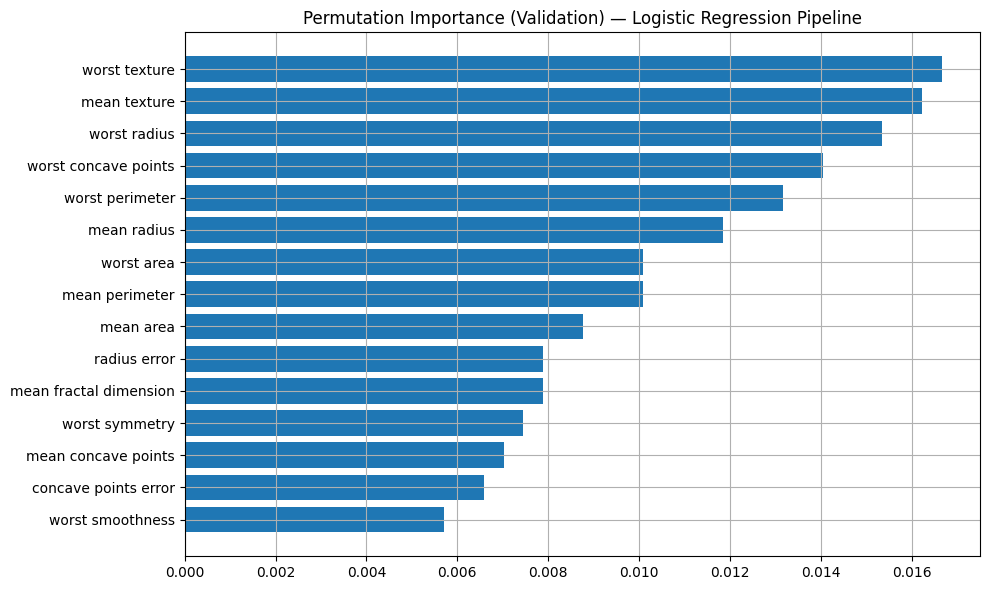

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_logreg, X_val, y_val,
    n_repeats=20,
    random_state=SEED,
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure()
top = imp.head(15).iloc[::-1]
plt.barh(top["feature"], top["importance_mean"])
plt.title("Permutation Importance (Validation) — Logistic Regression Pipeline")
plt.tight_layout()
plt.show()


### Summary
Rather than fixing the decision threshold at 0.5, we explicitly tune it using validation data.

Treating malignant as the positive class, we examine the precision–recall tradeoff across thresholds.

Lower thresholds reduce false negatives (higher recall) at the cost of more false positives, while higher thresholds do the opposite.

For this analysis, we select a threshold of 0.25, which achieves ~98% malignant recall while maintaining >90% precision.

This operating point reflects a screening-oriented objective where missing malignant cases is more costly than over-flagging benign ones.  

Based on this analysis, we select a threshold of **0.25** on P(malignant) as a reasonable operating point.

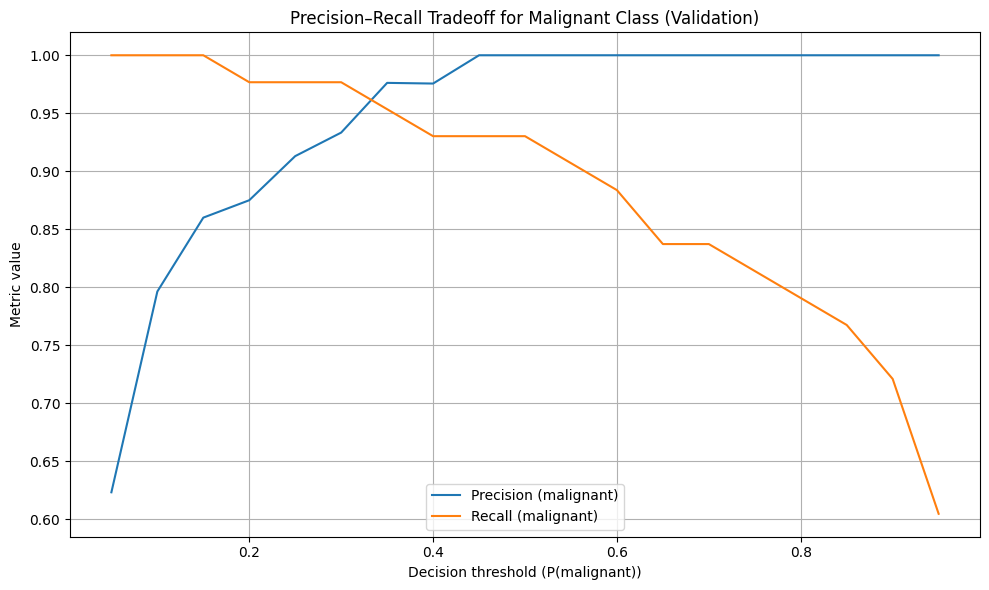

In [ ]:
plt.figure()
plt.plot(df_thr["thr"], df_thr["precision_malig"], label="Precision (malignant)")
plt.plot(df_thr["thr"], df_thr["recall_malig"], label="Recall (malignant)")
plt.xlabel("Decision threshold (P(malignant))")
plt.ylabel("Metric value")
plt.title("Precision–Recall Tradeoff for Malignant Class (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

## Final Evaluation on Held-Out Test Set

At this point, we **freeze** our modeling decisions (model family + hyperparameters + threshold) using training/validation only.  
We now evaluate exactly once on the held-out **test set** to estimate generalization performance.  

**Final choice:** We use the tuned Logistic Regression model as the final model because it achieves near-ceiling performance with strong interpretability; the more complex model did not provide a meaningful improvement under the chosen evaluation criteria.

FINAL MODEL: best_logreg (tuned Logistic Regression pipeline)
FINAL THRESHOLD POLICY: maximize recall_malig subject to precision_malig >= 0.90 (on validation)
thr_star (threshold on P(malignant)) = 0.25

Test ROC-AUC (malignant as positive): 0.996031746031746

Classification report (test):

              precision    recall  f1-score   support

   malignant       0.82      0.98      0.89        42
      benign       0.98      0.88      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.93      0.91       114
weighted avg       0.92      0.91      0.91       114



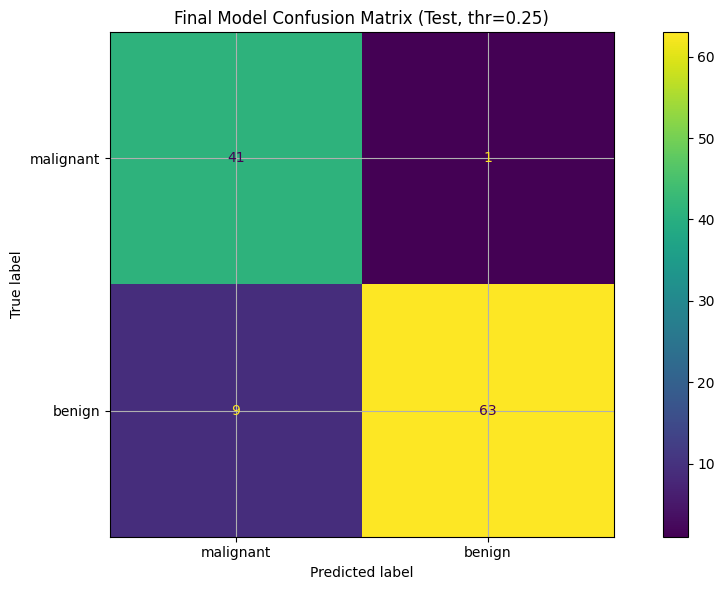

In [ ]:
# --- Final test-set evaluation (uses frozen model + frozen threshold) ---

# Sanity checks (fail fast if something is missing)
assert "best_logreg" in globals(), "best_logreg not found — did GridSearchCV run?"
assert "thr_star" in globals(), "thr_star not found — did threshold selection run?"
assert "X_test" in globals() and "y_test" in globals(), "Test split not found."
assert "target_names" in globals(), "target_names not found."

final_model = best_logreg

# Compute P(malignant) on test (sklearn breast cancer convention: 0=malignant, 1=benign)
classes = final_model.named_steps["model"].classes_
idx_malignant = int(np.where(classes == 0)[0][0])
proba_malig_test = final_model.predict_proba(X_test)[:, idx_malignant]

# Predict malignant if P(malignant) >= thr_star
y_true_malig_test = (y_test.values == 0).astype(int)              # 1 means malignant (custom)
y_pred_malig_test = (proba_malig_test >= thr_star).astype(int)    # 1 means malignant (custom)

# Convert back to original labels for reporting: 0=malignant, 1=benign
y_pred_test = np.where(y_pred_malig_test == 1, 0, 1)

print("FINAL MODEL:", "best_logreg (tuned Logistic Regression pipeline)")
print(f"FINAL THRESHOLD POLICY: maximize recall_malig subject to precision_malig >= 0.90 (on validation)")
print(f"thr_star (threshold on P(malignant)) = {thr_star:.2f}\n")

print("Test ROC-AUC (malignant as positive):", roc_auc_score(y_true_malig_test, proba_malig_test))
print("\nClassification report (test):\n")
print(classification_report(y_test, y_pred_test, target_names=target_names))

show_confusion_matrix(y_test, y_pred_test, title=f"Final Model Confusion Matrix (Test, thr={thr_star:.2f})")


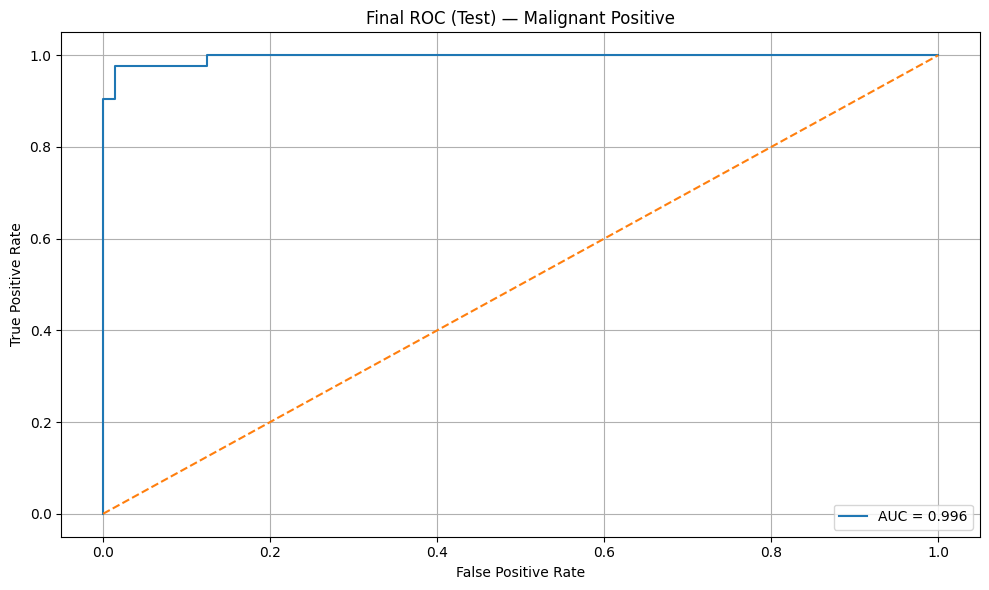

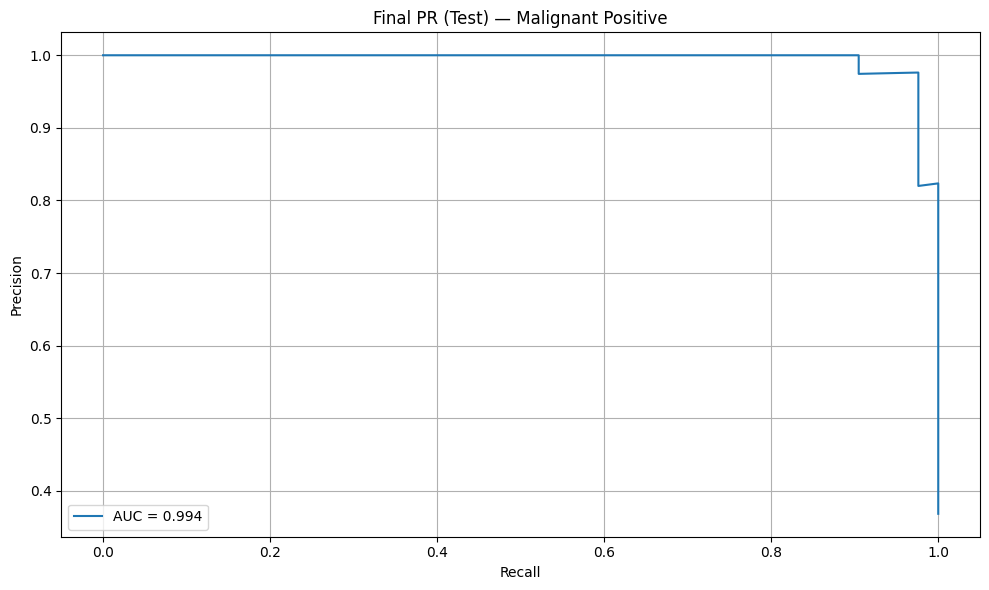

In [ ]:
if "plot_roc" in globals():
    plot_roc(y_true_malig_test, proba_malig_test, title="Final ROC (Test) — Malignant Positive")
if "plot_precision_recall" in globals():
    plot_precision_recall(y_true_malig_test, proba_malig_test, title="Final PR (Test) — Malignant Positive")


## Calibration (Probability Quality)

ROC-AUC measures ranking quality, but it does not guarantee that predicted probabilities are well-calibrated.

In many decision-making contexts (e.g., threshold policies, risk scoring), we want predicted probabilities to reflect empirical frequencies.
Here we evaluate calibration on the validation set using reliability curves and Brier score, and apply post-hoc calibration.

Brier score (val) BEFORE calibration: 0.0277


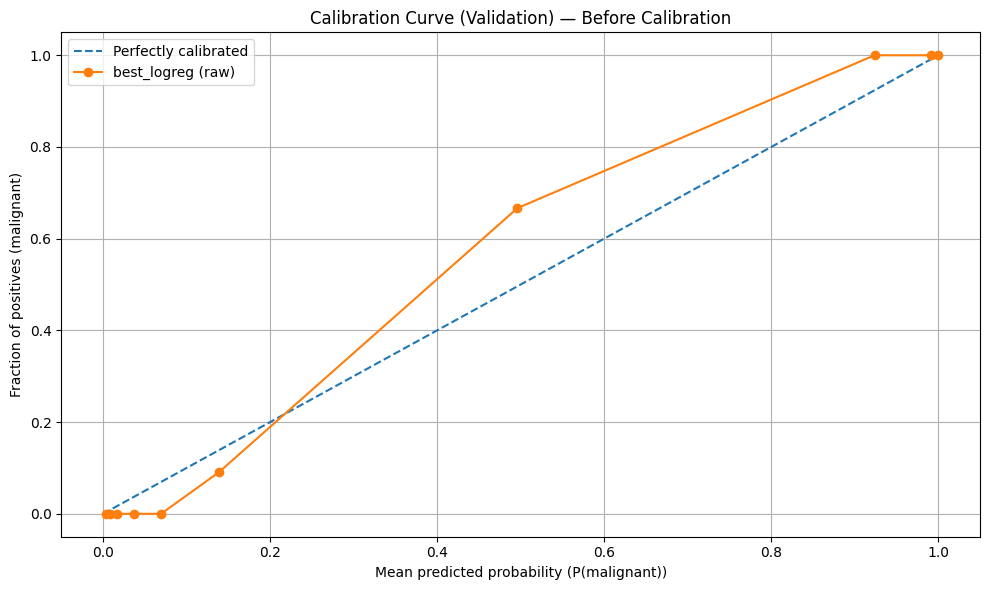

Brier score (val) AFTER calibration (sigmoid): 0.0248


/Users/Jake/miniforge3/envs/tf310/lib/python3.10/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


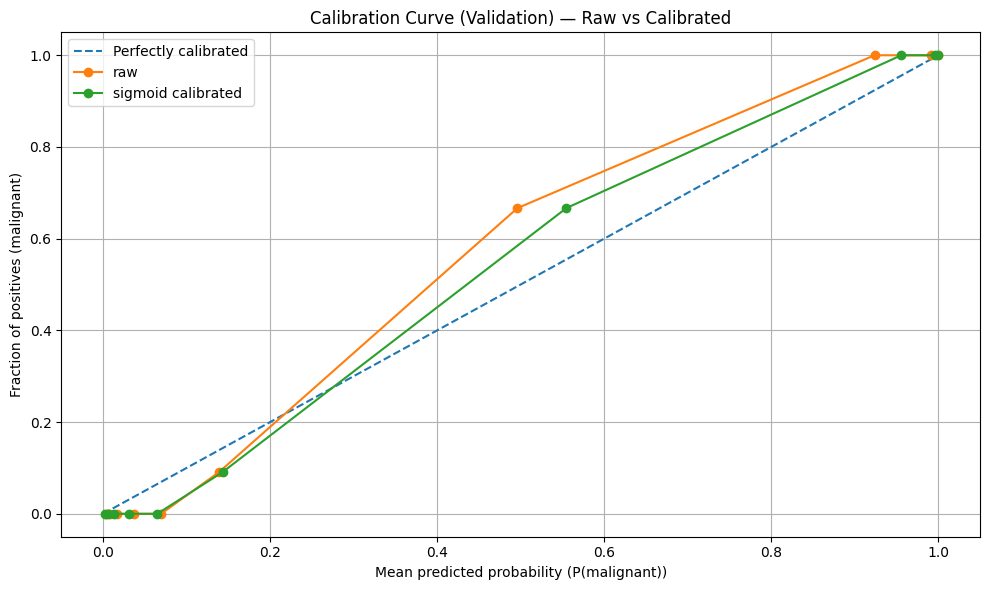

Brier score (val) AFTER calibration (isotonic): 0.0168
Chosen calibrated model: isotonic


/Users/Jake/miniforge3/envs/tf310/lib/python3.10/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# --- Helper: get P(malignant) from any fitted sklearn estimator with predict_proba ---
def proba_malignant(estimator, X):
    # Works for pipelines too
    if hasattr(estimator, "named_steps") and "model" in estimator.named_steps:
        classes = estimator.named_steps["model"].classes_
    else:
        classes = estimator.classes_
    idx_malig = int(np.where(classes == 0)[0][0])  # class 0 = malignant in this dataset
    return estimator.predict_proba(X)[:, idx_malig]

# Binary targets for calibration metrics (1 = malignant)
y_val_malig = (y_val.values == 0).astype(int)

# --- BEFORE calibration ---
val_proba_malig_raw = proba_malignant(best_logreg, X_val)
brier_raw = brier_score_loss(y_val_malig, val_proba_malig_raw)

# Reliability curve
frac_pos_raw, mean_pred_raw = calibration_curve(
    y_val_malig, val_proba_malig_raw, n_bins=10, strategy="quantile"
)

print(f"Brier score (val) BEFORE calibration: {brier_raw:.4f}")

plt.figure()
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.plot(mean_pred_raw, frac_pos_raw, marker="o", label="best_logreg (raw)")
plt.xlabel("Mean predicted probability (P(malignant))")
plt.ylabel("Fraction of positives (malignant)")
plt.title("Calibration Curve (Validation) — Before Calibration")
plt.legend()
plt.tight_layout()
plt.show()

# --- AFTER calibration ---
# We calibrate the already-fit model using the validation set as a held-out calibration set.
# (Note: this consumes the validation set for calibration; avoid re-tuning thresholds on this same data afterwards.)
cal_sigmoid = CalibratedClassifierCV(best_logreg, method="sigmoid", cv="prefit")
cal_sigmoid.fit(X_val, y_val)

val_proba_malig_sig = proba_malignant(cal_sigmoid, X_val)
brier_sig = brier_score_loss(y_val_malig, val_proba_malig_sig)

frac_pos_sig, mean_pred_sig = calibration_curve(
    y_val_malig, val_proba_malig_sig, n_bins=10, strategy="quantile"
)

print(f"Brier score (val) AFTER calibration (sigmoid): {brier_sig:.4f}")

plt.figure()
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.plot(mean_pred_raw, frac_pos_raw, marker="o", label="raw")
plt.plot(mean_pred_sig, frac_pos_sig, marker="o", label="sigmoid calibrated")
plt.xlabel("Mean predicted probability (P(malignant))")
plt.ylabel("Fraction of positives (malignant)")
plt.title("Calibration Curve (Validation) — Raw vs Calibrated")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: try isotonic (can overfit on small data; compare Brier)
cal_iso = CalibratedClassifierCV(best_logreg, method="isotonic", cv="prefit")
cal_iso.fit(X_val, y_val)

val_proba_malig_iso = proba_malignant(cal_iso, X_val)
brier_iso = brier_score_loss(y_val_malig, val_proba_malig_iso)
print(f"Brier score (val) AFTER calibration (isotonic): {brier_iso:.4f}")

# Pick a calibrated model (simple rule: lower Brier on validation)
calibrated_model = cal_sigmoid if brier_sig <= brier_iso else cal_iso
print("Chosen calibrated model:", "sigmoid" if calibrated_model is cal_sigmoid else "isotonic")

Brier score (test) raw:        0.02968665773799994
Brier score (test) calibrated: 0.032159056996489604


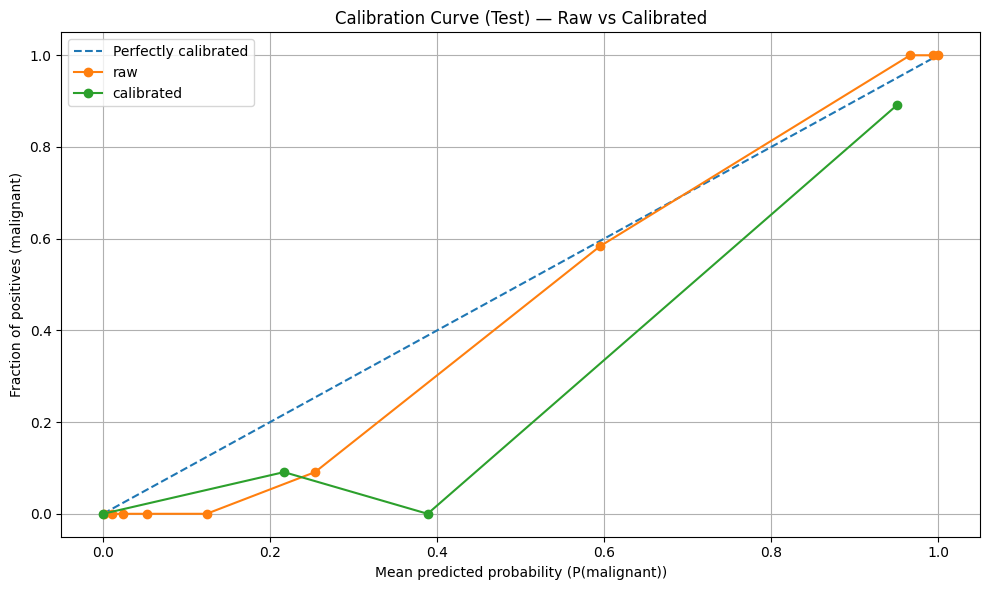

In [ ]:
y_test_malig = (y_test.values == 0).astype(int)

test_proba_raw = proba_malignant(best_logreg, X_test)
test_proba_cal = proba_malignant(calibrated_model, X_test)

print("Brier score (test) raw:       ", brier_score_loss(y_test_malig, test_proba_raw))
print("Brier score (test) calibrated:", brier_score_loss(y_test_malig, test_proba_cal))

frac_pos_raw_t, mean_pred_raw_t = calibration_curve(y_test_malig, test_proba_raw, n_bins=10, strategy="quantile")
frac_pos_cal_t, mean_pred_cal_t = calibration_curve(y_test_malig, test_proba_cal, n_bins=10, strategy="quantile")

plt.figure()
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.plot(mean_pred_raw_t, frac_pos_raw_t, marker="o", label="raw")
plt.plot(mean_pred_cal_t, frac_pos_cal_t, marker="o", label="calibrated")
plt.xlabel("Mean predicted probability (P(malignant))")
plt.ylabel("Fraction of positives (malignant)")
plt.title("Calibration Curve (Test) — Raw vs Calibrated")
plt.legend()
plt.tight_layout()
plt.show()


## Limitations

This notebook is intentionally focused on clarity and disciplined evaluation rather than claiming real-world clinical readiness. Several limitations are worth noting:

- **Dataset size and curation:** The Breast Cancer Wisconsin dataset is small, clean, and well-curated. Many features are engineered summary statistics with strong signal, which makes the problem easier than many real-world medical datasets.
- **Feature availability:** All features are numeric and preprocessed; this avoids challenges common in practice such as missing values, noisy measurements, or data collected across heterogeneous devices or institutions.
- **Threshold policy context:** The chosen decision threshold reflects a demonstration policy (maximize malignant recall subject to precision ≥ 0.90). In real deployments, thresholds should be selected using explicit cost, risk, and stakeholder considerations.
- **No external validation:** Performance is reported on a held-out test split from the same dataset distribution. Generalization to new populations or institutions is not assessed.

These limitations do not invalidate the analysis, but they do constrain how results should be interpreted.


## Confidence & Stability (Cross-Validation)

Because the dataset is relatively small, single train/validation/test splits can introduce variance.
To assess the stability of the final model, we evaluate performance using stratified K-fold cross-validation on the training data.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv_results = cross_validate(
    best_logreg,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    metric.replace("test_", ""): [
        cv_results[f"test_{metric}"].mean(),
        cv_results[f"test_{metric}"].std(),
    ]
    for metric in scoring
}, index=["mean", "std"]).T

display(cv_summary)


,mean,std
accuracy,0.979454,0.015014
roc_auc,0.993920,0.007173
precision,0.977273,0.020328
recall,0.990698,0.011393
f1,0.983800,0.011733


The relatively small standard deviations suggest that the model’s performance is stable across folds, and that reported results are not driven by a single favorable split.

## What I’d Do Next in Production

If this model were part of a real system, the next steps would focus less on model complexity and more on robustness, alignment, and monitoring:

- **External validation:** Evaluate performance on data from a different source or institution to assess distribution shift and generalization.
- **Explicit cost modeling:** Work with stakeholders to define the relative costs of false negatives vs false positives and choose thresholds accordingly.
- **Calibration monitoring:** Track probability calibration over time, especially if class prevalence or data collection processes change.
- **Data quality checks:** Add checks for missing values, out-of-range inputs, and feature drift.
- **Human-in-the-loop workflows:** Integrate predictions as decision support rather than automation, particularly for high-risk cases.
- **Periodic re-training:** Establish criteria for retraining or recalibration as new labeled data becomes available.

In many real-world settings, these system-level considerations have more impact than incremental model improvements.